# Multi-channel linearized gap equation

This notebook rewrites the structure of `chi2_old.m` in Python and keeps the main building blocks as close as possible to the MATLAB code:

- the normal-state Hamiltonians `H0` and `H0p`
- the eight pairing vertices `Gam[:,:,1:8]`
- the fermionic bubbles `bubble` and `bubblep`
- the block-structured pairing kernel `Mchi`
- the eigenvalue problem `eigs(-pref * Mchi, ...)`

Compared with the earlier single-channel notebook, this version restores the multi-channel structure of the linearized gap equation. The markdown is also expanded so it is easier to compare each Python block with the original MATLAB implementation.


## Practical note on defaults

The original MATLAB script uses `Nk_base = 31`, which means the sampled grid has `Nk = Nk_base + 1 = 32` points along each momentum direction because both `-pi` and `pi` are included. That choice makes the full kernel very large:

$$
\mathrm{dim}(M_\chi) = 8 N_k^2.
$$

For interactive notebook use, the default below is lighter than the MATLAB setting. To get closer to the original script, set `Nk_base = 31` and keep in mind that both runtime and memory usage will increase sharply.


In [91]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import inv
from scipy.interpolate import RectBivariateSpline
from scipy.sparse.linalg import eigs


@dataclass
class ModelParams:
    # Grid: MATLAB uses Nk_base = 31 and then sets Nk = Nk_base + 1.
    Nk_base: int = 31

    # Band and interaction parameters.
    # Paper convention in the shown section: t=1, t_a'=-0.3, t_b'=0.2,
    # no SOC, and r/J=1.5. Here m plays the role of r, so m/J=1.5.
    m: float = 1.0
    J: float = 0.66
    mu: float = 0.5
    tp: float = 0.2
    tpp: float = -0.3
    lam: float = 0.3
    t: float = 1.0
    T: float =  0.01

    # Matsubara cutoff: MATLAB sums n = -Nw-1, ..., Nw.
    Nw: int = 30

    # Small momentum regularizer used in chi2_old.m.
    delta: float = 1e-15

    # Number of leading eigenvalues to request.
    num_eigs: int = 10

    # Classification tolerance for the leading mode.
    classify_tol: float = 1e-9

    # Save arrays to disk.
    save_outputs: bool = True


params = ModelParams()
params

ModelParams(Nk_base=31, m=1.0, J=0.66, mu=0.5, tp=0.2, tpp=-0.3, lam=0.3, t=1.0, T=0.01, Nw=30, delta=1e-15, num_eigs=10, classify_tol=1e-09, save_outputs=True)

## Pauli matrices, momentum grid, and model ingredients

The original MATLAB code works with a four-component normal-state Hamiltonian and builds matrices using Kronecker products of Pauli matrices. We keep the same notation here. The Pauli matrices are

$$
\begin{aligned}
\tau_0 &= \begin{pmatrix}1 & 0 \\ 0 & 1\end{pmatrix}, &
\tau_1 &= \begin{pmatrix}0 & 1 \\ 1 & 0\end{pmatrix}, \\
\tau_2 &= \begin{pmatrix}0 & -i \\ i & 0\end{pmatrix}, &
\tau_3 &= \begin{pmatrix}1 & 0 \\ 0 & -1\end{pmatrix}.
\end{aligned}
$$

The normal-state Hamiltonian used in the kernel is

$$
\begin{aligned}
H_0(k_x,k_y) ={}& \left[-(t' + t'')\left(\cos k_x + \cos k_y\right)-\mu\right] \, \tau_0\otimes\tau_0 \\
&{} -4t\cos\frac{k_x}{2}\cos\frac{k_y}{2} \, \tau_1\otimes\tau_0 \\
&{} + \lambda\sin\frac{k_x}{2}\sin\frac{k_y}{2} \, \tau_2\otimes\tau_3 \\
&{} + (t' - t'')\left(\cos k_x - \cos k_y\right) \, \tau_3\otimes\tau_0 .
\end{aligned}
$$

The companion matrix `H0p` used for `bubblep` follows the MATLAB script:

$$
\begin{aligned}
H'_0(k_x,k_y) ={}& \left[-(t' + t'')\left(\cos k_x + \cos k_y\right)-\mu\right] \, \tau_0\otimes\tau_0 \\
&{} +4t\cos\frac{k_x}{2}\cos\frac{k_y}{2} \, \tau_1\otimes\tau_0 \\
&{} - \lambda\sin\frac{k_x}{2}\sin\frac{k_y}{2} \, \tau_2\otimes\tau_3 \\
&{} + (t' - t'')\left(\cos k_x - \cos k_y\right) \, \tau_3\otimes\tau_0 .
\end{aligned}
$$

So compared with `H0`, only the $\tau_1\otimes\tau_0$ hopping term and the spin-orbit-like $\tau_2\otimes\tau_3$ term change sign.

The code follows the paper ordering of the eight attractive pairing vertices in Eq. (S5):

$$
\begin{aligned}
\Gamma_1 &= \tau_0\otimes\sigma_0, &
\Gamma_2 &= \tau_3\otimes\sigma_3, \\
\Gamma_3 &= \tau_3\otimes\sigma_0, &
\Gamma_4 &= \tau_0\otimes\sigma_3, \\
\Gamma_5 &= \tau_1\otimes\sigma_2, &
\Gamma_6 &= \tau_2\otimes\sigma_1, \\
\Gamma_7 &= \tau_1\otimes\sigma_1, &
\Gamma_8 &= \tau_2\otimes\sigma_2.
\end{aligned}
$$

The linearized gap vector is therefore represented numerically as

$$
\Delta(k_x,k_y)=\sum_{a=1}^{8}\Delta_a(k_x,k_y)\Gamma_a,
$$

where the unknown functions `Delta_a(kx, ky)` are solved on the momentum grid rather than assumed from a harmonic expansion.

The momentum grid is also matched to the MATLAB convention:

$$
k_x, k_y \in \left\{-\pi, -\pi + \frac{2\pi}{N_k^{\mathrm{base}}}, \ldots, \pi\right\}.
$$

Because the endpoint is included, the actual number of grid points per direction is

$$
N_k = N_k^{\mathrm{base}} + 1.
$$

This is slightly different from the more common `endpoint=False` grid that avoids duplicating `-pi` and `pi`, but here we intentionally follow the MATLAB script.


In [92]:
tau0 = np.array([[1, 0], [0, 1]], dtype=complex)
tau1 = np.array([[0, 1], [1, 0]], dtype=complex)
tau2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
tau3 = np.array([[1, 0], [0, -1]], dtype=complex)


def make_grid(p: ModelParams):
    x = -np.pi + 2.0 * np.pi * np.arange(p.Nk_base + 1) / p.Nk_base
    y = -np.pi + 2.0 * np.pi * np.arange(p.Nk_base + 1) / p.Nk_base
    qx, qy = np.meshgrid(x, y, indexing="xy")
    Nk = p.Nk_base + 1
    vqx = qx.reshape(Nk * Nk)
    vqy = qy.reshape(Nk * Nk)
    dxy = (x[1] - x[0]) * (y[1] - y[0])
    pref = dxy * p.T / (2.0 * np.pi) ** 2
    return x, y, qx, qy, vqx, vqy, Nk, dxy, pref


def H0(kx, ky, p: ModelParams):
    return (
        (-(p.tp + p.tpp) * (np.cos(kx) + np.cos(ky)) - p.mu) * np.kron(tau0, tau0)
        + (-4.0 * p.t * np.cos(kx / 2.0) * np.cos(ky / 2.0)) * np.kron(tau1, tau0)
        + (p.lam * np.sin(kx / 2.0) * np.sin(ky / 2.0)) * np.kron(tau2, tau3)
        + ((p.tp - p.tpp) * (np.cos(kx) - np.cos(ky))) * np.kron(tau3, tau0)
    )


def H0p(kx, ky, p: ModelParams):
    return (
        (-(p.tp + p.tpp) * (np.cos(kx) + np.cos(ky)) - p.mu) * np.kron(tau0, tau0)
        + (4.0 * p.t * np.cos(kx / 2.0) * np.cos(ky / 2.0)) * np.kron(tau1, tau0)
        + (-p.lam * np.sin(kx / 2.0) * np.sin(ky / 2.0)) * np.kron(tau2, tau3)
        + ((p.tp - p.tpp) * (np.cos(kx) - np.cos(ky))) * np.kron(tau3, tau0)
    )


def build_gamma_matrices():
    # Paper Eq. (S5) ordering for the eight attractive channels.
    Gam = np.zeros((8, 4, 4), dtype=complex)
    Gam[0] = np.kron(tau0, tau0)  # Gamma1
    Gam[1] = np.kron(tau3, tau3)  # Gamma2
    Gam[2] = np.kron(tau3, tau0)  # Gamma3
    Gam[3] = np.kron(tau0, tau3)  # Gamma4
    Gam[4] = np.kron(tau1, tau2)  # Gamma5
    Gam[5] = np.kron(tau2, tau1)  # Gamma6
    Gam[6] = np.kron(tau1, tau1)  # Gamma7
    Gam[7] = np.kron(tau2, tau2)  # Gamma8
    return Gam


x, y, qx, qy, vqx, vqy, Nk, dxy, pref = make_grid(params)
Ntot = Nk * Nk
Gam = build_gamma_matrices()
eye4 = np.eye(4, dtype=complex)

print(f"Nk_base = {params.Nk_base}, Nk = {Nk}, Ntot = {Ntot}")
print(f"prefactor = {pref:.6e}")


Nk_base = 31, Nk = 32, Ntot = 1024
prefactor = 1.040583e-05


## Bubble functions `bubble` and `bubblep`

The MATLAB script computes two fermionic bubble tensors:

$$
\mathrm{bubble}(\mathbf{k}, a, b)
= \sum_n \mathrm{Tr}\left[G_p(i\omega_n, \mathbf{k}) \Gamma_a G_h(i\omega_n, \mathbf{k}) \Gamma_b\right],
$$

and an analogous `bubblep` constructed from `H0p`.

In the SOC calculation the reduced kernel is not restricted to the three diagonal channel blocks `1:4`, `5:6`, and `7:8`. In particular, the couplings between `Gamma1:Gamma4` and `Gamma7:Gamma8` can be nonzero. Therefore the code below computes the full `8 x 8` channel bubble tensors and lets the matrix elements themselves determine which entries vanish.


In [93]:
def build_hamiltonian_tables(vqx, vqy, p: ModelParams):
    H_table = np.zeros((len(vqx), 4, 4), dtype=complex)
    Hp_table = np.zeros((len(vqx), 4, 4), dtype=complex)
    for ik, (kx, ky) in enumerate(zip(vqx, vqy)):
        H_table[ik] = H0(kx, ky, p)
        Hp_table[ik] = H0p(kx, ky, p)
    return H_table, Hp_table


def trace_against_gamma(left, Gam):
    return np.einsum("ij,bji->b", left, Gam)


def compute_bubbles(vqx, vqy, Gam, p: ModelParams, verbose=True):
    H_table, Hp_table = build_hamiltonian_tables(vqx, vqy, p)
    bubble = np.zeros((len(vqx), 8, 8), dtype=complex)
    bubblep = np.zeros((len(vqx), 8, 8), dtype=complex)

    if verbose:
        print("Computing full 8x8 bubble tensors ...")

    for ik in range(len(vqx)):
        Hk = H_table[ik]
        Hkp = Hp_table[ik]
        accum = np.zeros((8, 8), dtype=complex)
        accump = np.zeros((8, 8), dtype=complex)

        for n in range(-p.Nw - 1, p.Nw + 1):
            freq = (2 * n + 1) * np.pi * p.T
            iwn = 1j * freq * eye4

            Gp = inv(iwn - Hk)
            Gh = inv(iwn + Hk.T)
            Gpp = inv(iwn - Hkp)
            Ghp = inv(iwn + Hkp.T)

            for gid1, G1 in enumerate(Gam):
                accum[gid1, :] += trace_against_gamma(Gp @ G1 @ Gh, Gam)
                accump[gid1, :] += trace_against_gamma(Gpp @ G1 @ Ghp, Gam)

        bubble[ik] = accum
        bubblep[ik] = accump

    return bubble, bubblep


## Pairing kernel `Mchi`

The large kernel matrix has dimension `8 * Ntot` by `8 * Ntot`, where `Ntot = Nk^2`. Its row index is a pair `(a, i)` and its column index is a pair `(b, j)`, with channel labels `a,b = 1, ..., 8` and momentum-grid points

$$
\mathbf{p}_i=(p_{x,i},p_{y,i}),\qquad
\mathbf{k}_j=(k_{x,j},k_{y,j}).
$$

The interaction pieces in the code are

$$
\chi_{s}(\mathbf{q})=
\frac{1}{4\left[\delta(q_x^2+q_y^2)+m+sJ\cos(q_x/2)\cos(q_y/2)\right]},
\qquad s=\pm 1.
$$

Thus `minus_pm`, `minus_pp`, `plus_pm`, and `plus_pp` correspond to

$$
\begin{aligned}
\chi_-(\mathbf{p}_i-\mathbf{k}_j),\quad
\chi_-(\mathbf{p}_i+\mathbf{k}_j),\quad
\chi_+(\mathbf{p}_i-\mathbf{k}_j),\quad
\chi_+(\mathbf{p}_i+\mathbf{k}_j),
\end{aligned}
$$

where `minus` means the denominator contains `m - J cos(qx/2) cos(qy/2)`, and `plus` means it contains `m + J cos(qx/2) cos(qy/2)`.

Let

$$
B_{ab}(\mathbf{k}_j)=\mathrm{bubble}(\mathbf{k}_j,a,b),\qquad
B'_{ab}(\mathbf{k}_j)=\mathrm{bubblep}(\mathbf{k}_j,a,b).
$$

Following the reduced-kernel sign structure, define

$$
\eta_b=\begin{cases}
-1, & b=1,2,3,4,7,8,\\
+1, & b=5,6,
\end{cases}
\qquad
\rho_b=\begin{cases}
+1, & b=1,2,3,4,\\
-1, & b=5,6,7,8.
\end{cases}
$$

Then the channel matrix elements are assembled as

$$
\begin{aligned}
(M_\chi)_{ai,bj}={}&
B_{ab}(\mathbf{k}_j)
\left[\chi_-(\mathbf{p}_i-\mathbf{k}_j)+\eta_b\chi_-(\mathbf{p}_i+\mathbf{k}_j)\right]\\
&{}+\rho_b B'_{ab}(\mathbf{k}_j)
\left[\chi_+(\mathbf{p}_i-\mathbf{k}_j)+\eta_b\chi_+(\mathbf{p}_i+\mathbf{k}_j)\right].
\end{aligned}
$$

This formula reproduces the old diagonal-sector expressions for column channels `1:4`, `5:6`, and `7:8`, but it no longer forces the off-block couplings to zero. The full `8 x 8` channel structure is therefore retained; entries that vanish do so because the corresponding bubble traces or sign combinations vanish numerically, not because the assembly loop skipped them.

The final eigenvalue problem is

$$
\left[-\mathrm{pref}\,M_\chi\right]v=\lambda v,
\qquad
\mathrm{pref}=\frac{T\,\Delta k_x\Delta k_y}{(2\pi)^2}.
$$

This mirrors the MATLAB call `eigs(-pref*Mchi, 10)`.


In [94]:
CHANNEL_ETA = np.array([-1, -1, -1, -1, +1, +1, -1, -1], dtype=float)
CHANNEL_RHO = np.array([+1, +1, +1, +1, -1, -1, -1, -1], dtype=float)


def chi_piece(qx, qy, p: ModelParams, sign_of_J: int):
    q2 = qx * qx + qy * qy
    denom = p.delta * q2 + p.m + sign_of_J * p.J * np.cos(qx / 2.0) * np.cos(qy / 2.0)
    return 0.25 / denom


def interaction_terms(px, py, kx, ky, p: ModelParams):
    dq_x = px - kx
    dq_y = py - ky
    sq_x = px + kx
    sq_y = py + ky

    minus_pm = chi_piece(dq_x, dq_y, p, sign_of_J=-1)
    minus_pp = chi_piece(sq_x, sq_y, p, sign_of_J=-1)
    plus_pm = chi_piece(dq_x, dq_y, p, sign_of_J=+1)
    plus_pp = chi_piece(sq_x, sq_y, p, sign_of_J=+1)
    return minus_pm, minus_pp, plus_pm, plus_pp


def build_interaction_tables(vqx, vqy, p: ModelParams):
    px = vqx[:, None]
    py = vqy[:, None]
    kx = vqx[None, :]
    ky = vqy[None, :]
    return interaction_terms(px, py, kx, ky, p)


def build_Mchi(vqx, vqy, bubble, bubblep, p: ModelParams, verbose=True):
    Ntot = len(vqx)
    Mchi = np.zeros((8 * Ntot, 8 * Ntot), dtype=complex)
    minus_pm, minus_pp, plus_pm, plus_pp = build_interaction_tables(vqx, vqy, p)

    for gid1 in range(8):
        if verbose:
            print(f"Assembling channel row Gamma{gid1 + 1}/8")

        row_slice = slice(gid1 * Ntot, (gid1 + 1) * Ntot)

        for gid2 in range(8):
            col_slice = slice(gid2 * Ntot, (gid2 + 1) * Ntot)
            eta = CHANNEL_ETA[gid2]
            rho = CHANNEL_RHO[gid2]

            minus_part = minus_pm + eta * minus_pp
            plus_part = plus_pm + eta * plus_pp
            block = bubble[:, gid1, gid2][None, :] * minus_part
            block += rho * bubblep[:, gid1, gid2][None, :] * plus_part
            Mchi[row_slice, col_slice] = block

    return Mchi


def solve_eigenproblem(Mchi, pref, num_eigs):
    A = -pref * Mchi
    dim = A.shape[0]

    if dim <= num_eigs + 2:
        evals, evecs = np.linalg.eig(A)
    else:
        evals, evecs = eigs(A, k=num_eigs, which="LR")

    order = np.argsort(evals.real)[::-1]
    evals = evals[order]
    evecs = evecs[:, order]
    return evals, evecs


## Leading-channel identification and diagnostics

The matrix assembly stores the eigenvector in channel-major order: all momentum points for `Gamma1`, then all momentum points for `Gamma2`, and so on. For plotting and diagnostics we convert it into an array of shape `(Nk, Nk, 8)` and classify the dominant pairing channel by checking which group of components carries the largest weight.

Because an eigenvector has an arbitrary complex phase, the helper `align_eigenvector_phase` first rotates the vector so that its largest component is real and positive. The plotted and classified object is then

$$
f_a(k_{x,i},k_{y,j})=\operatorname{Re}\left[e^{-i\phi}v_{a,ij}\right],
\qquad a=1,\ldots,8,
$$

where `real_mode_grid(vec, Nk)` stores these components as an array `ft[j,i,a]`, with the first two axes matching the `qx, qy` meshgrid arrays.

The channel weight printed by the code is the discrete complex \(L^1\)-weight after fixing the global eigenvector phase:

$$
w_a=\sum_{i,j}\left|\Delta_a(k_{x,i},k_{y,j})\right|.
$$

This is important with SOC: an induced partner channel, such as \(\Gamma_6\), can be nearly imaginary relative to the dominant \(\Gamma_5\) component. Taking only the real part would incorrectly make that component look absent.

The block weights used for the leading-channel decision are

$$
\begin{aligned}
W_{14} &= w_1+w_2+w_3+w_4, \\
W_{56} &= w_5+w_6, \\
W_{78} &= w_7+w_8.
\end{aligned}
$$

The dominant block is the largest of these three numbers. The labels are then assigned as follows:

$$
\begin{array}{ccl}
W_{14}\ \text{largest} &\Rightarrow& \text{p sector},\\
W_{56}\ \text{largest} &\Rightarrow& \text{s'/d' sector},\\
W_{78}\ \text{largest} &\Rightarrow& \text{p' sector}.
\end{array}
$$

Inside the `Gamma5:Gamma6` sector, the code can additionally compare a representative value of the `Gamma5` component before and after flipping the first grid axis:

$$
s_1=\operatorname{sgn}\left[f_1(i_0,j_0)\right],\qquad
s_2=\operatorname{sgn}\left[f_1(N_k-1-i_0,j_0)\right].
$$

If \(s_1s_2<0\), this sign diagnostic points to a `d'`-like form factor; otherwise it points to an `s'`-like form factor. The harmonic projection table below is usually the cleaner way to make the final `s'` versus `d'` call.

For the first few modes, the code also applies QR orthonormalization,

$$
Q R = \left[v_1,v_2,v_3,v_4\right],
$$

which plays the role of the MATLAB `gram_schmidt(v(:,1:4))` call. This is useful when several eigenvalues are nearly degenerate: the individual raw eigenvectors can rotate inside the degenerate subspace, while the span of the leading modes is more meaningful.

Finally, the sine-harmonic diagnostics project the `G5:G8` components onto simple form factors. For a basis function \(g_\ell(k_x,k_y)\), the reported projection is

$$
P_{\ell a}^{(n)}=
\frac{N_k}{4\pi^2}\sum_{i,j}g_\ell(k_{x,i},k_{y,j})\,Q^{(n)}_a(k_{x,i},k_{y,j}),
\qquad a=5,6,7,8.
$$

The code uses

$$
g_\ell\in\{\sin k_x,\ \sin k_y,\ \sin(k_x-k_y),\ \sin(k_x+k_y)\}.
$$

These projections are diagnostic only: they help name the momentum form factor after the gap eigenvector has been found; they are not an assumed harmonic expansion used to solve the eigenvalue problem.


In [95]:
CHANNEL_LABELS = [
    "Gamma1 = tau0 x sigma0  (p-wave sector)",
    "Gamma2 = tau3 x sigma3  (p-wave sector)",
    "Gamma3 = tau3 x sigma0  (p-wave sector)",
    "Gamma4 = tau0 x sigma3  (p-wave sector)",
    "Gamma5 = tau1 x sigma2  (s'/d' sector)",
    "Gamma6 = tau2 x sigma1  (SOC-mixed s'/d' partner)",
    "Gamma7 = tau1 x sigma1  (p' sector)",
    "Gamma8 = tau2 x sigma2  (SOC-mixed p' partner)",
]

CHANNEL_GROUPS = [
    ("Gamma1-Gamma4", slice(0, 4), "p"),
    ("Gamma5-Gamma6", slice(4, 6), "s'/d'"),
    ("Gamma7-Gamma8", slice(6, 8), "p'"),
]


def align_eigenvector_phase(vec):
    """Fix the arbitrary eigenvector phase before taking the real part."""
    idx = np.argmax(np.abs(vec))
    if np.abs(vec[idx]) < 1e-14:
        return vec
    return vec * np.exp(-1j * np.angle(vec[idx]))


def complex_mode_grid(vec, Nk):
    """Convert a phase-aligned channel-major eigenvector into ft[ky, kx, gamma]."""
    vec = align_eigenvector_phase(vec)
    return vec.reshape(8, Nk, Nk).transpose(1, 2, 0)


def real_mode_grid(vec, Nk):
    """Real part of the phase-aligned mode, mainly for sign tests and real-component plots."""
    return np.real(complex_mode_grid(vec, Nk))


def mode_grid_part(vec, Nk, part="real"):
    """Select real, imaginary, absolute-value, or complex mode data for diagnostics/plots."""
    ft = complex_mode_grid(vec, Nk)
    if part == "real":
        return np.real(ft)
    if part == "imag":
        return np.imag(ft)
    if part == "abs":
        return np.abs(ft)
    if part == "complex":
        return ft
    raise ValueError("part must be 'real', 'imag', 'abs', or 'complex'")


def sign_or_zero(x, tol=1e-12):
    if abs(x) < tol:
        return 0.0
    return float(np.sign(x))


def classify_leading_mode(vec, Nk, tol=1e-9):
    ft_complex = complex_mode_grid(vec, Nk)
    ft = np.real(ft_complex)
    weights = np.sum(np.abs(ft_complex), axis=(0, 1))
    group_values = [np.sum(weights[group_slice]) for _, group_slice, _ in CHANNEL_GROUPS]
    dominant_group = int(np.argmax(group_values))

    if group_values[dominant_group] <= tol:
        label = "undetermined"
    elif dominant_group == 0:
        label = "p"
    elif dominant_group == 1:
        label = "s'/d'"
    elif dominant_group == 2:
        label = "p'"

    return label, weights, ft


def orthonormalize_columns(vectors):
    q, _ = np.linalg.qr(vectors)
    return q


def basis_projection_report(Q, qx, qy, Nk):
    basis1 = np.sin(qx)
    report = []
    nmodes = min(4, Q.shape[1])

    for mode in range(nmodes):
        ft = real_mode_grid(Q[:, mode], Nk)
        projection = Nk * np.array([
            np.sum(basis1 * ft[:, :, 4]),
            np.sum(basis1 * ft[:, :, 5]),
            np.sum(basis1 * ft[:, :, 6]),
            np.sum(basis1 * ft[:, :, 7]),
        ]) / (4.0 * np.pi ** 2)
        report.append(projection)

    return np.array(report)


def interpolate_contour_grid(x, y, data, plot_grid_points=301, spline_order=3):
    """Interpolate data from the solver grid to a denser grid for smoother plotting only."""
    from scipy.interpolate import RectBivariateSpline

    if plot_grid_points is None or plot_grid_points <= max(len(x), len(y)):
        return x, y, data

    order_x = min(spline_order, len(x) - 1)
    order_y = min(spline_order, len(y) - 1)
    xi = np.linspace(x[0], x[-1], plot_grid_points)
    yi = np.linspace(y[0], y[-1], plot_grid_points)
    spline = RectBivariateSpline(y, x, data, kx=order_y, ky=order_x, s=0)
    return xi, yi, spline(yi, xi)


def contour_levels_for_data(data, base_levels, num_levels, level_scale="shared"):
    """Choose contour levels, either shared across panels or local to one component."""
    data_min = float(np.min(data))
    data_max = float(np.max(data))
    if np.ptp(data) <= 1e-12:
        return np.array([])

    if level_scale == "component":
        # Exclude endpoints because contours at exact extrema are often invisible.
        return np.linspace(data_min, data_max, num_levels + 2)[1:-1]
    if level_scale != "shared":
        raise ValueError("level_scale must be 'shared' or 'component'")

    levels = base_levels[(base_levels >= data_min) & (base_levels <= data_max)]
    if len(levels) == 0:
        levels = np.linspace(data_min, data_max, min(num_levels, 7) + 2)[1:-1]
    return levels


def plot_leading_mode_components(
    vec,
    x,
    y,
    Nk,
    channel_ids=(4, 5, 6, 7),
    mode_number=1,
    num_levels=9,
    plot_grid_points=301,
    level_scale="shared",
    spline_order=3,
    mode_part="real",
):
    """Plot selected Gamma components of one raw eigenmode as contour maps.

    mode_part can be "real", "imag", "abs", or "real_imag". The last option
    draws real and imaginary parts in two rows for each selected channel.
    level_scale can be "shared", "row", or "component". For "real_imag",
    "row" is usually best because induced imaginary components are smaller.
    plot_grid_points controls only visual interpolation; the eigenproblem itself
    is still solved on the original Nk by Nk momentum grid.
    """
    if mode_part == "real_imag":
        part_names = ["real", "imag"]
    else:
        part_names = [mode_part]

    data_entries = []
    for part_name in part_names:
        ft = mode_grid_part(vec, Nk, part=part_name)
        for gid in channel_ids:
            data_entries.append((part_name, gid, Nk * ft[:, :, gid]))

    if level_scale == "row":
        base_levels_by_part = {}
        for part_name in part_names:
            part_vmax = max(
                float(np.max(np.abs(data)))
                for entry_part, _, data in data_entries
                if entry_part == part_name
            )
            if part_vmax < 1e-14:
                part_vmax = 1.0
            base_levels_by_part[part_name] = np.linspace(-part_vmax, part_vmax, num_levels)
    else:
        vmax = max(float(np.max(np.abs(data))) for _, _, data in data_entries)
        if vmax < 1e-14:
            vmax = 1.0
        base_levels = np.linspace(-vmax, vmax, num_levels)

    nrows = len(part_names)
    ncols = len(channel_ids)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(3.3 * ncols, 3.2 * nrows),
        constrained_layout=True,
        squeeze=False,
    )

    for idx, (part_name, gid, data) in enumerate(data_entries):
        row = idx // ncols
        col = idx % ncols
        ax = axes[row, col]
        if level_scale == "row":
            levels = contour_levels_for_data(data, base_levels_by_part[part_name], num_levels, level_scale="shared")
        else:
            levels = contour_levels_for_data(data, base_levels, num_levels, level_scale=level_scale)
        plot_x, plot_y, plot_data = interpolate_contour_grid(
            x,
            y,
            data,
            plot_grid_points=plot_grid_points,
            spline_order=spline_order,
        )

        if len(levels) > 0:
            cs = ax.contour(plot_x, plot_y, plot_data, levels=levels, cmap="viridis", linewidths=1.35)
            ax.clabel(cs, inline=True, fontsize=8, fmt="%.2g")

        ax.set_title(rf"mode {mode_number}, $\Gamma_{{{gid + 1}}}$, {part_name}")
        ax.set_xlabel(r"$k_x$")
        if col == 0:
            ax.set_ylabel(r"$k_y$")
        ax.set_xticks([-np.pi, 0.0, np.pi])
        ax.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
        ax.set_yticks([-np.pi, 0.0, np.pi])
        ax.set_yticklabels([r"$-\pi$", "0", r"$\pi$"])
        ax.set_xlim(x[0], x[-1])
        ax.set_ylim(y[0], y[-1])
        ax.set_aspect("equal")

    return fig


def normalize_component_to_peak(data, target_peak=-2.0):
    """Scale one component so its largest-magnitude value becomes target_peak."""
    peak_idx = np.unravel_index(np.argmax(np.abs(data)), data.shape)
    peak_value = float(data[peak_idx])
    if abs(peak_value) < 1e-14:
        return data.copy()
    return target_peak * data / peak_value


def fixed_step_levels(vmin=-2.0, vmax=0.0, step=0.2):
    """Return increasing contour levels with a fixed paper-style spacing."""
    if step <= 0:
        raise ValueError("step must be positive")
    lo, hi = sorted((float(vmin), float(vmax)))
    nsteps = int(round((hi - lo) / step))
    return np.linspace(lo, hi, nsteps + 1)


def plot_paper_style_component(
    vec,
    x,
    y,
    Nk,
    gid=4,
    mu=None,
    title=None,
    target_peak=-2.0,
    level_step=0.2,
    plot_grid_points=401,
    spline_order=3,
    cmap="jet",
    formula_text=r"$\Delta_s(k) \sim \cos\frac{k_x}{2}\cos\frac{k_y}{2}+\cdots$",
):
    """Plot one Gamma component in a paper-like normalized contour style."""
    ft = real_mode_grid(vec, Nk)
    raw_data = Nk * ft[:, :, gid]
    data = normalize_component_to_peak(raw_data, target_peak=target_peak)
    plot_x, plot_y, plot_data = interpolate_contour_grid(
        x,
        y,
        data,
        plot_grid_points=plot_grid_points,
        spline_order=spline_order,
    )

    levels = fixed_step_levels(min(target_peak, 0.0), max(target_peak, 0.0), step=level_step)
    data_min = float(np.min(plot_data))
    data_max = float(np.max(plot_data))
    levels = levels[(levels >= data_min - 1e-10) & (levels <= data_max + 1e-10)]

    fig, ax = plt.subplots(figsize=(4.2, 4.8))
    fig.subplots_adjust(left=0.18, right=0.96, top=0.88, bottom=0.22)
    if len(levels) > 0:
        cs = ax.contour(plot_x, plot_y, plot_data, levels=levels, cmap=cmap, linewidths=0.9)
        ax.clabel(cs, inline=True, fontsize=7, fmt="%g")

    if title is None:
        title = rf"$\mu = {mu:g}:\ s^\prime$-wave" if mu is not None else rf"$s^\prime$-wave, $\Gamma_{{{gid + 1}}}$"
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(r"$k_x$", fontsize=13)
    ax.set_ylabel(r"$k_y$", fontsize=13)
    ax.set_xticks([-np.pi, 0.0, np.pi])
    ax.set_xticklabels([r"$-\pi$", "", r"$\pi$"], fontsize=12)
    ax.set_yticks([-np.pi, 0.0, np.pi])
    ax.set_yticklabels([r"$-\pi$", "", r"$\pi$"], fontsize=12)
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(y[0], y[-1])
    ax.set_aspect("equal")
    if formula_text:
        fig.text(0.5, 0.06, formula_text, ha="center", va="bottom", fontsize=13)
    return fig


def array_memory_gb(*arrays):
    total = 0
    for arr in arrays:
        if arr is not None:
            total += arr.nbytes
    return total / 1e9


def format_real(x, width=11):
    return f"{float(np.real(x)):>{width}.4e}"


def print_table(title, headers, rows):
    rows = [[str(item) for item in row] for row in rows]
    widths = [len(h) for h in headers]
    for row in rows:
        widths = [max(w, len(item)) for w, item in zip(widths, row)]

    print(title)
    print("-" * len(title))
    print("  ".join(h.ljust(w) for h, w in zip(headers, widths)))
    print("  ".join("-" * w for w in widths))
    for row in rows:
        print("  ".join(item.ljust(w) for item, w in zip(row, widths)))


def channel_weight_rows(weights):
    total = np.sum(weights)
    frac = np.zeros_like(weights, dtype=float) if total == 0 else np.real(weights / total)
    return [
        [f"Gamma{i + 1}", CHANNEL_LABELS[i], format_real(weights[i]), f"{100 * frac[i]:6.2f}%"]
        for i in range(8)
    ]


def component_weight_summary(vec, Nk, tol=1e-9):
    label, weights, ft = classify_leading_mode(vec, Nk, tol=tol)
    total = np.sum(weights)
    fractions = np.zeros_like(weights, dtype=float) if total == 0 else np.real(weights / total)
    dominant_gid = int(np.argmax(weights))
    return label, weights, fractions, dominant_gid, ft


def harmonic_basis_functions(qx, qy):
    return [
        ("d' ~ sin(kx/2) sin(ky/2)", np.sin(qx / 2.0) * np.sin(qy / 2.0)),
        ("s' ~ cos(kx/2) cos(ky/2)", np.cos(qx / 2.0) * np.cos(qy / 2.0)),
        ("p+ ~ sin((kx+ky)/2)", np.sin((qx + qy) / 2.0)),
        ("p- ~ sin((kx-ky)/2)", np.sin((qx - qy) / 2.0)),
    ]


def project_component_to_basis(component, basis):
    numerator = np.sum(component * basis)
    basis_norm2 = np.sum(basis * basis)
    comp_norm2 = np.sum(component * component)
    coefficient = numerator / basis_norm2 if basis_norm2 > 1e-14 else 0.0
    overlap = numerator / np.sqrt(basis_norm2 * comp_norm2) if basis_norm2 > 1e-14 and comp_norm2 > 1e-14 else 0.0
    return float(coefficient), float(overlap)


def dominant_component_rows(evecs, qx, qy, Nk, tol=1e-9, num_modes=6):
    rows = []
    bases = harmonic_basis_functions(qx, qy)
    nmodes = min(num_modes, evecs.shape[1])

    for mode in range(nmodes):
        label, weights, fractions, dominant_gid, ft = component_weight_summary(evecs[:, mode], Nk, tol=tol)
        component = ft[:, :, dominant_gid]
        projections = []
        for basis_name, basis in bases:
            coefficient, overlap = project_component_to_basis(component, basis)
            projections.append((abs(overlap), basis_name, coefficient, overlap))

        _, best_basis, best_coeff, best_overlap = max(projections, key=lambda item: item[0])
        rows.append([
            str(mode + 1),
            f"Gamma{dominant_gid + 1}",
            CHANNEL_LABELS[dominant_gid],
            format_real(weights[dominant_gid]),
            f"{100 * fractions[dominant_gid]:6.2f}%",
            best_basis,
            f"{best_coeff:+.3e}",
            f"{best_overlap:+.3f}",
            label,
        ])

    return rows


def dominant_component_projection_rows(vec, qx, qy, Nk, tol=1e-9):
    label, weights, fractions, dominant_gid, ft = component_weight_summary(vec, Nk, tol=tol)
    component = ft[:, :, dominant_gid]
    rows = []

    for basis_name, basis in harmonic_basis_functions(qx, qy):
        coefficient, overlap = project_component_to_basis(component, basis)
        rows.append([
            f"Gamma{dominant_gid + 1}",
            CHANNEL_LABELS[dominant_gid],
            basis_name,
            f"{coefficient:+.3e}",
            f"{overlap:+.3f}",
            f"{abs(overlap):.3f}",
        ])

    return rows


def mode_summary_rows(evals, evecs, Nk, tol=1e-9, num_modes=6):
    nmodes = min(num_modes, len(evals), evecs.shape[1])
    lambda0 = np.real(evals[0])
    rows = []

    for mode in range(nmodes):
        label, weights, _ = classify_leading_mode(evecs[:, mode], Nk, tol=tol)
        group_values = [np.sum(weights[group_slice]) for _, group_slice, _ in CHANNEL_GROUPS]
        dominant_idx = int(np.argmax(group_values))
        ratio = np.real(evals[mode]) / lambda0 if abs(lambda0) > 1e-14 else np.nan
        rows.append([
            str(mode + 1),
            format_real(evals[mode]),
            format_real(np.imag(evals[mode]), width=9),
            f"{ratio:9.5f}",
            f"{1.0 - ratio:9.5f}",
            CHANNEL_GROUPS[dominant_idx][0],
            label,
            f"{group_values[0]:.3e}",
            f"{group_values[1]:.3e}",
            f"{group_values[2]:.3e}",
        ])
    return rows


def symmetry_decision_rows(vec, Nk, tol=1e-9):
    label, weights, ft = classify_leading_mode(vec, Nk, tol=tol)
    group_values = [np.sum(weights[group_slice]) for _, group_slice, _ in CHANNEL_GROUPS]
    dominant_group = int(np.argmax(group_values))
    rows = [
        ["dominant group", CHANNEL_GROUPS[dominant_group][0], "largest block weight"],
        ["final label", label, "dominant block + sector rule"],
    ]

    if dominant_group == 1:
        i0 = min(2, Nk - 1)
        gamma5 = ft[:, :, 4]
        element1 = sign_or_zero(gamma5[i0, i0])
        element2 = sign_or_zero(np.flip(gamma5, axis=0)[i0, i0])
        relation = "opposite signs -> d'" if element1 * element2 < 0 else "same signs -> s'"
        rows.extend([
            ["Gamma5 sample sign", f"{element1:+.0f}", f"ft[{i0},{i0},Gamma5]"],
            ["flipped Gamma5 sign", f"{element2:+.0f}", f"flip_y(ft)[{i0},{i0},Gamma5]"],
            ["mirror test", relation, "used only in Gamma5-Gamma6 sector"],
        ])
    else:
        rows.append(["mirror test", "skipped", "only needed for s' vs d' in Gamma5-Gamma6"])

    return rows


def harmonic_projection_rows(Q, qx, qy, Nk, num_modes=4, top_n=4):
    bases = [
        ("sin(qx)", np.sin(qx)),
        ("sin(qy)", np.sin(qy)),
        ("sin(qx-qy)", np.sin(qx - qy)),
        ("sin(qx+qy)", np.sin(qx + qy)),
    ]
    rows = []

    for mode in range(min(num_modes, Q.shape[1])):
        ft = real_mode_grid(Q[:, mode], Nk)
        candidates = []
        for basis_name, basis in bases:
            projection = Nk * np.array([
                np.sum(basis * ft[:, :, gid]) for gid in range(4, 8)
            ]) / (4.0 * np.pi ** 2)
            candidates.append((np.linalg.norm(projection), basis_name, projection))

        for norm, basis_name, projection in sorted(candidates, reverse=True)[:top_n]:
            rows.append([
                str(mode + 1),
                basis_name,
                *(f"{value:+.3e}" for value in projection),
                f"{norm:.3e}",
            ])

    return rows


## Main pipeline

The driver cell below executes the same conceptual sequence as `chi2_old.m`:

1. build `bubble` and `bubblep`
2. assemble `Mchi`
3. solve the leading eigenvalue problem
4. classify the leading pairing channel
5. print a few diagnostics and optionally save arrays

For notebook work, `run_full_problem` is set to `False` by default, because even the reduced default grid can still take a while. Switch it to `True` when you want to run the full calculation.


Computing bubble and bubblep ...
Computing full 8x8 bubble tensors ...
Building Mchi ...
Assembling channel row Gamma1/8
Assembling channel row Gamma2/8
Assembling channel row Gamma3/8
Assembling channel row Gamma4/8
Assembling channel row Gamma5/8
Assembling channel row Gamma6/8
Assembling channel row Gamma7/8
Assembling channel row Gamma8/8
Solving eigensystem ...

=== Results ===
prefactor               : 1.040583e-05
approx array memory [GB]: 1.076
leading eigenvalue      : (0.9319988393768109+5.312590645215788e-18j)
lambda criterion        : if this kernel has the same normalization as the paper, Tc is where leading lambda(T) crosses 1
identified channel      : s'/d'

Leading modes
-------------
mode  Re(lambda)   Im(lambda)   lambda/lambda1  1-ratio    block          label  Gamma1-4   Gamma5-6   Gamma7-8 
----  -----------  -----------  --------------  ---------  -------------  -----  ---------  ---------  ---------
1      9.3200e-01  5.3126e-18     1.00000         0.00000  Gamma

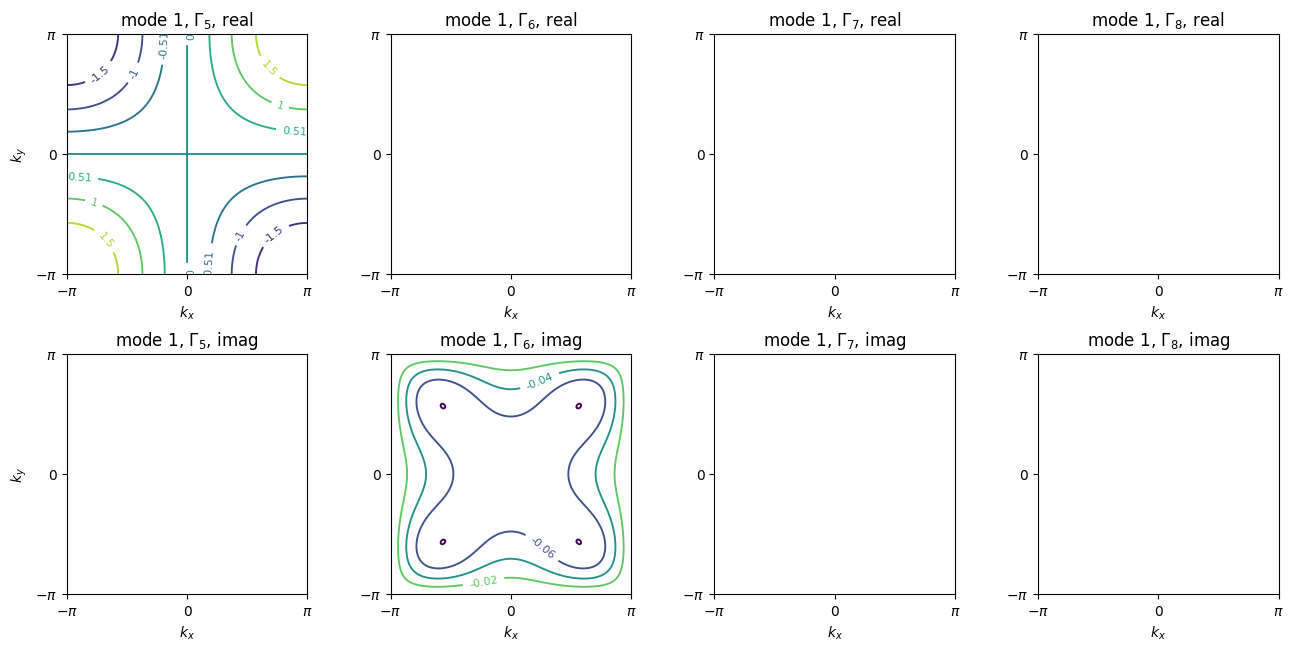

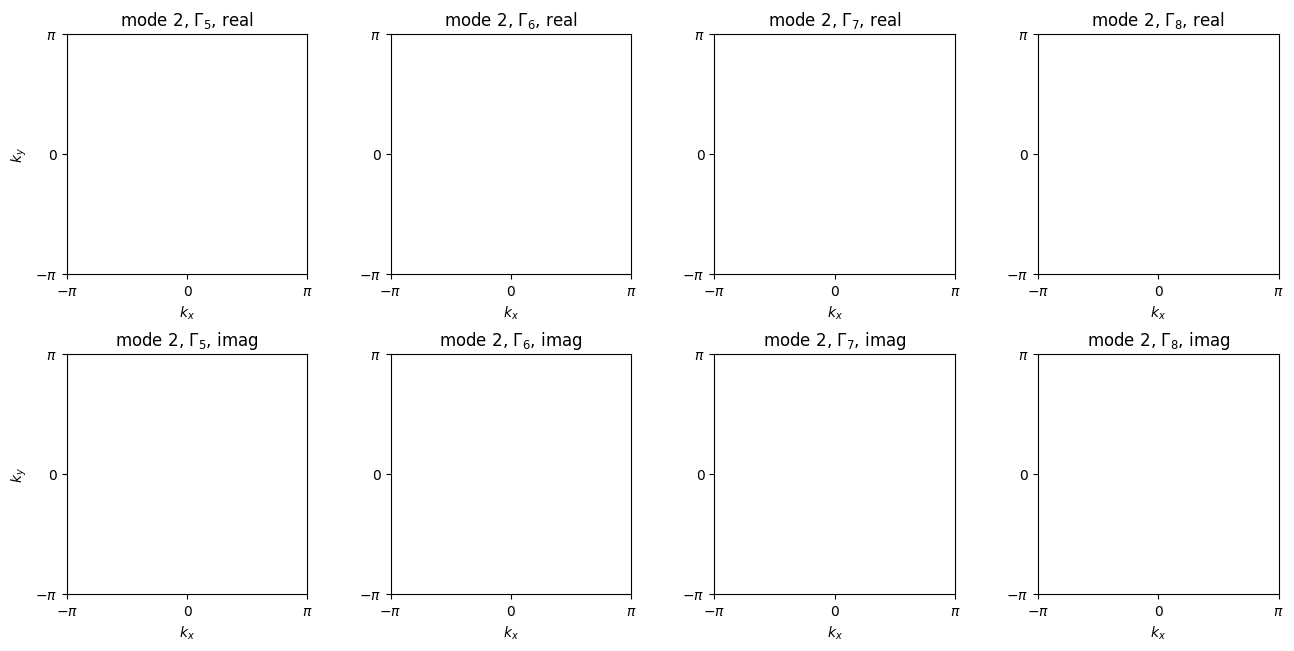

In [96]:
def run_pipeline(p: ModelParams, make_plots=False, verbose=True, plot_kwargs=None, plot_mode_numbers=(1,)):
    x, y, qx, qy, vqx, vqy, Nk, dxy, pref = make_grid(p)
    Gam = build_gamma_matrices()

    if verbose:
        print("Computing bubble and bubblep ...")
    bubble, bubblep = compute_bubbles(vqx, vqy, Gam, p, verbose=verbose)

    if verbose:
        print("Building Mchi ...")
    Mchi = build_Mchi(vqx, vqy, bubble, bubblep, p, verbose=verbose)

    if verbose:
        print("Solving eigensystem ...")
    evals, evecs = solve_eigenproblem(Mchi, pref, p.num_eigs)

    label, weights, ft = classify_leading_mode(evecs[:, 0], Nk, tol=p.classify_tol)
    Q = orthonormalize_columns(evecs[:, : min(4, evecs.shape[1])])
    basis_report = basis_projection_report(Q, qx, qy, Nk)
    summary_rows = mode_summary_rows(evals, evecs, Nk, tol=p.classify_tol)
    dominant_component_report = dominant_component_rows(evecs, qx, qy, Nk, tol=p.classify_tol)
    leading_component_projection = dominant_component_projection_rows(evecs[:, 0], qx, qy, Nk, tol=p.classify_tol)
    decision_rows = symmetry_decision_rows(evecs[:, 0], Nk, tol=p.classify_tol)
    projection_rows = harmonic_projection_rows(Q, qx, qy, Nk)

    if p.save_outputs:
        np.save("chi2_evals.npy", evals)
        np.save("chi2_evecs.npy", evecs)
        np.save("chi2_leading_mode_grid.npy", real_mode_grid(evecs[:, 0], Nk))
        np.save("chi2_channel_weights.npy", weights)

    print("\n=== Results ===")
    print(f"prefactor               : {pref:.6e}")
    print(f"approx array memory [GB]: {array_memory_gb(bubble, bubblep, Mchi):.3f}")
    print(f"leading eigenvalue      : {evals[0]}")
    print("lambda criterion        : if this kernel has the same normalization as the paper, Tc is where leading lambda(T) crosses 1")
    print(f"identified channel      : {label}")
    print()
    print_table(
        "Leading modes",
        ["mode", "Re(lambda)", "Im(lambda)", "lambda/lambda1", "1-ratio", "block", "label", "Gamma1-4", "Gamma5-6", "Gamma7-8"],
        summary_rows,
    )
    print()
    print_table("Leading-mode channel weights", ["Gamma", "basis matrix", "L1 weight", "fraction"], channel_weight_rows(weights))
    print()
    print_table(
        "Dominant component per mode",
        ["mode", "component", "basis matrix", "weight", "fraction", "best harmonic", "coeff", "overlap", "label"],
        dominant_component_report,
    )
    print()
    print_table(
        "Leading dominant-component harmonic projections",
        ["component", "basis matrix", "harmonic", "coeff", "overlap", "abs overlap"],
        leading_component_projection,
    )
    print()
    print_table("Leading-mode symmetry decision", ["check", "value", "meaning"], decision_rows)

    if p.save_outputs:
        print("\nSaved:")
        print("  chi2_evals.npy")
        print("  chi2_evecs.npy")
        print("  chi2_leading_mode_grid.npy")
        print("  chi2_channel_weights.npy")

    results = {
        "params": p,
        "grid": (x, y, qx, qy, vqx, vqy, Nk, dxy, pref),
        "bubble": bubble,
        "bubblep": bubblep,
        "Mchi": Mchi,
        "evals": evals,
        "evecs": evecs,
        "label": label,
        "weights": weights,
        "Q": Q,
        "basis_report": basis_report,
        "summary_rows": summary_rows,
        "dominant_component_report": dominant_component_report,
        "leading_component_projection": leading_component_projection,
        "decision_rows": decision_rows,
        "projection_rows": projection_rows,
    }

    if make_plots:
        if plot_kwargs is None:
            plot_kwargs = {}
        if isinstance(plot_mode_numbers, int):
            plot_mode_numbers = (plot_mode_numbers,)
        for mode_number in plot_mode_numbers:
            mode_index = int(mode_number) - 1
            if mode_index < 0 or mode_index >= evecs.shape[1]:
                print(f"Skipping mode {mode_number}: only {evecs.shape[1]} modes were computed.")
                continue
            plot_leading_mode_components(
                evecs[:, mode_index],
                x,
                y,
                Nk,
                channel_ids=(4, 5, 6, 7),
                mode_number=mode_number,
                **plot_kwargs,
            )
            plt.show()

    return results


# Default behavior: run a tiny preview so the result tables are visible
# without launching the expensive full grid calculation.
run_full_problem = True
run_preview_problem = False
make_result_plots = True
make_paper_style_plot = False
plot_mode_numbers = (1, 2)  # plot raw eigenmodes; useful when mode 1 and mode 2 are degenerate
plot_grid_points = 301  # visual interpolation grid; set None to plot the raw solver grid
plot_num_levels = 9
plot_level_scale = "row"  # use "shared", "row", or "component"; row is useful for real_imag plots
plot_component_part = "real_imag"  # use "real", "imag", "abs", or "real_imag"
plot_options = {
    "plot_grid_points": plot_grid_points,
    "num_levels": plot_num_levels,
    "level_scale": plot_level_scale,
    "mode_part": plot_component_part,
}
paper_plot_options = {
    "gid": 6,  # Gamma7 because channel indices are zero-based
    "target_peak": -2.0,
    "level_step": 0.2,
    "plot_grid_points": 401,
}

if run_full_problem:
    results = run_pipeline(
        params,
        make_plots=make_result_plots,
        verbose=True,
        plot_kwargs=plot_options,
        plot_mode_numbers=plot_mode_numbers,
    )
elif run_preview_problem:
    preview_params = ModelParams(**{
        **params.__dict__,
        "Nk_base": 5,
        "num_eigs": min(params.num_eigs, 6),
        "save_outputs": False,
    })
    print("Running a small preview calculation so the result tables are visible.")
    print("For production results, set run_full_problem = True and choose params.Nk_base, e.g. 31 for the MATLAB grid.")
    results = run_pipeline(
        preview_params,
        make_plots=make_result_plots,
        verbose=False,
        plot_kwargs=plot_options,
        plot_mode_numbers=plot_mode_numbers,
    )
else:
    print("No calculation was run.")
    print("Set run_preview_problem = True for a small demo output, or run_full_problem = True for the full calculation.")
    print("For a closer match to chi2_old.m, also set params.Nk_base = 31.")

if make_paper_style_plot and "results" in locals():
    x, y, qx, qy, vqx, vqy, Nk, dxy, pref = results["grid"]
    plot_paper_style_component(
        results["evecs"][:, 0],
        x,
        y,
        Nk,
        mu=results["params"].mu,
        **paper_plot_options,
    )
    plt.show()


## Reading the output

A few quick interpretations of the printed diagnostics:

- `Leading modes`: compares the first few eigenmodes. `lambda/lambda1` close to 1 means another channel is nearly degenerate with the leading one; `1-ratio` is the same kind of separation diagnostic as the MATLAB line `1-d(3)/d(1)`.
- `Leading-mode channel weights`: shows how much of the leading eigenvector lives in each of the eight `Gamma` components. These weights are computed as `w_i = sum_k |Delta_i(k)|` after reshaping the eigenvector into `Delta_i(kx, ky)`.
- `Dominant component per mode`: for each low-lying mode, finds the single largest `Gamma_i` component by this weight, then projects only that component onto the article-style harmonics `sin(kx/2) sin(ky/2)`, `cos(kx/2) cos(ky/2)`, and `sin((kx +/- ky)/2)`. This is the table to use when reading the mode as `d'`, `s'`, or `p'`-like.
- `Leading dominant-component harmonic projections`: shows the full harmonic projection list for the dominant component of the leading mode. `coeff` is the least-squares coefficient in that harmonic direction; `overlap` is the normalized inner product, so `abs overlap` closer to 1 means a cleaner match.
- The figures produced by `make_result_plots = True` show the raw eigenmodes selected by `plot_mode_numbers`, in the selected `Gamma5:Gamma8` components. All four panels share the same contour-level scale by default, so subdominant components stay visually small instead of being rescaled to look important.
- `Leading-mode symmetry decision`: summarizes the dominant channel-group weight. With the paper ordering, the diagnostic groups are `Gamma1:Gamma4` for p-wave, `Gamma5:Gamma6` for s'/d', and `Gamma7:Gamma8` for p'. These are classification groups, not a restriction that the full kernel is block diagonal. Inside the `Gamma5:Gamma6` sector, the flip sign test is only a quick diagnostic for s' versus d'; the harmonic projection table is the preferred check.

The saved arrays are mainly meant for post-processing and plotting. In particular, `chi2_leading_mode_grid.npy` stores the phase-aligned real part of the leading eigenvector reshaped to `(Nk, Nk, 8)`, which is convenient when comparing form factors channel by channel.

Why there is no required harmonic expansion step: the linearized gap equation is being diagonalized directly on the momentum grid and in the finite internal `Gamma` basis. The eigenvector itself is already the discretized gap function, with components `Delta_a(kx, ky)` for `a = 1, ..., 8`. A harmonic expansion such as projecting onto `sin(qx)`, `sin(qy)`, `cos(qx)-cos(qy)`, and so on is therefore optional interpretation/post-processing. It becomes necessary only if you want compact analytic coefficients, a controlled truncated basis calculation, or a more detailed symmetry decomposition than the MATLAB script's channel-weight/sign-test classifier.

About the common statement `lambda = 1`: in most papers the linearized gap equation is written as `lambda(T) Delta = K(T) Delta`, and the transition temperature is defined by the crossing condition `lambda_max(Tc) = 1`. A value larger than 1 at a fixed temperature usually means that this temperature is already below the instability scale, or that the kernel normalization/coupling convention is different. The small preview calculation in this notebook is only for checking the output format, so its absolute eigenvalue should not be compared directly with a paper figure.
